In [1]:
# ==============================
# TP Régression non paramétrique
# Version Python commentée
# ==============================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.model_selection import KFold


In [3]:
# Nombre de points pour représenter la vraie fonction (courbe lisse)
T = 1000

# Grille dense entre 0 et 1
t = np.linspace(0, 1, T)

# Définition des 4 fonctions vraies

truef1 = 0.5 + 0.2*np.cos(4*np.pi*t) + 0.1*np.cos(24*np.pi*t)

truef2 = 0.2 + 0.6*((t > 1/3) & (t <= 0.75))

truef3 = 4*np.sin(4*np.pi*t) - np.sign(t - 0.3) - np.sign(0.72 - t) + 5

truef4 = np.sqrt(t*(1-t))*np.sin((2*np.pi*1.05)/(t+0.05)) + 0.5


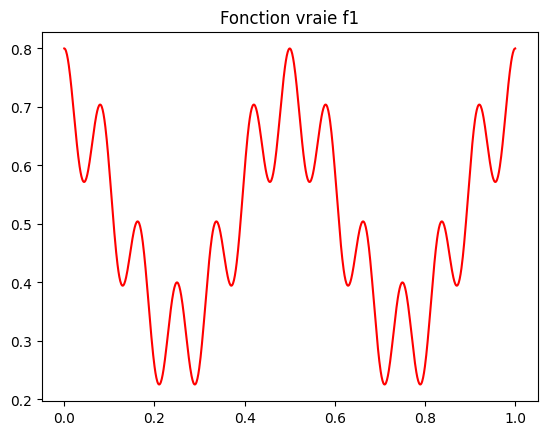

In [4]:
plt.figure()
plt.plot(t, truef1, color="red")
plt.title("Fonction vraie f1")
plt.show()


In [5]:
# Nombre d'observations
n = 100

# Design régulier entre 0 et 1
x = np.linspace(0, 1, n)

# Rapport signal/bruit
rsnr = 5

# Valeur vraie sur les points x
f1 = 0.5 + 0.2*np.cos(4*np.pi*x) + 0.1*np.cos(24*np.pi*x)

# Niveau de bruit
sigma1 = np.std(f1) / rsnr

# Données observées Y = f(x) + bruit
Y1 = f1 + np.random.normal(0, sigma1, n)


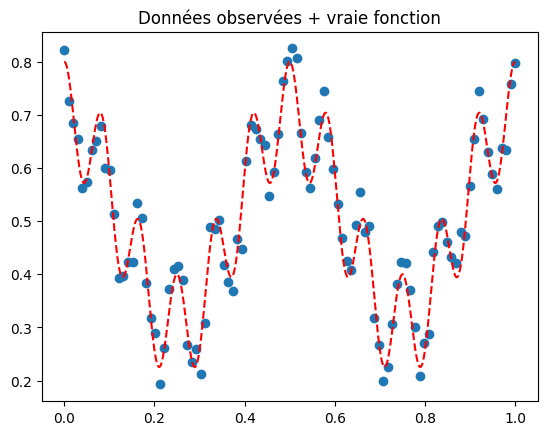

In [6]:
plt.figure()
plt.scatter(x, Y1)
plt.plot(t, truef1, color="red", linestyle="--")
plt.title("Données observées + vraie fonction")
plt.show()


In [7]:
def kernel_regression(x_train, y_train, x_eval, h):
    """
    Régression à noyau gaussien
    x_train : points observés
    y_train : valeurs observées
    x_eval  : points où on estime la fonction
    h       : bande passante
    """
    y_pred = []

    for x0 in x_eval:
        # Calcul des poids gaussiens
        weights = norm.pdf((x_train - x0)/h)

        # Estimateur Nadaraya-Watson
        y0 = np.sum(weights * y_train) / np.sum(weights)
        y_pred.append(y0)

    return np.array(y_pred)


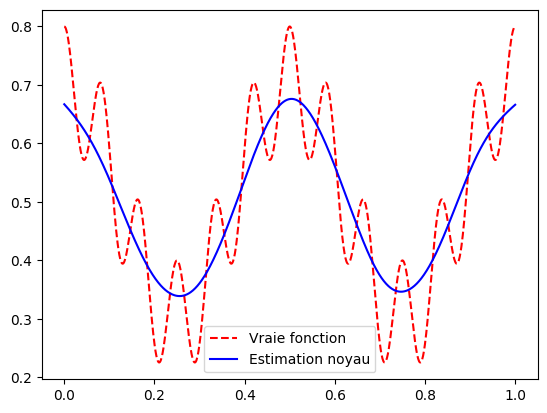

In [8]:
h = 0.05

y_kernel = kernel_regression(x, Y1, t, h)

plt.figure()
plt.plot(t, truef1, color="red", linestyle="--", label="Vraie fonction")
plt.plot(t, y_kernel, color="blue", label="Estimation noyau")
plt.legend()
plt.show()


In [9]:
mse = np.mean((truef1 - y_kernel)**2)
print("MSE noyau =", mse)


MSE noyau = 0.005799523151844953


In [10]:
from sklearn.linear_model import LinearRegression

def local_polynomial_regression(x_train, y_train, x_eval, h, degree=1):
    y_pred = []

    for x0 in x_eval:
        # Poids gaussiens
        weights = norm.pdf((x_train - x0)/h)

        # Construction matrice polynomiale
        X_design = np.vstack([ (x_train - x0)**d for d in range(degree+1) ]).T

        model = LinearRegression()
        model.fit(X_design, y_train, sample_weight=weights)

        # β0 est la prédiction en x0
        y_pred.append(model.intercept_)

    return np.array(y_pred)


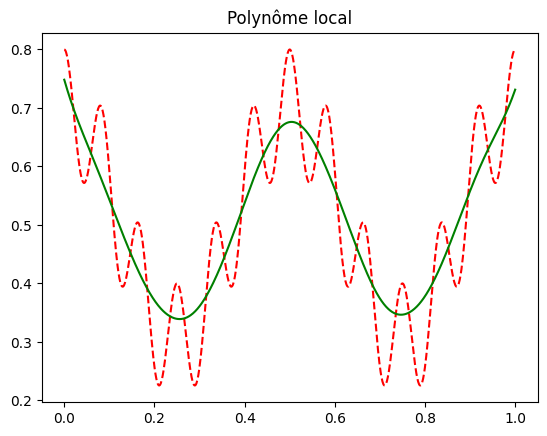

MSE polynôme local = 0.00546702727935755


In [12]:
h = 0.05
degree = 1

y_poly = local_polynomial_regression(x, Y1, t, h, degree)

plt.figure()
plt.plot(t, truef1, color="red", linestyle="--")
plt.plot(t, y_poly, color="green")
plt.title("Polynôme local")
plt.show()

print("MSE polynôme local =", np.mean((truef1 - y_poly)**2))


In [13]:
def cross_validation_bandwidth(x, y, h_values):
    kf = KFold(n_splits=5, shuffle=True, random_state=1)
    errors = []

    for h in h_values:
        mse_fold = []

        for train_idx, test_idx in kf.split(x):
            x_train, x_test = x[train_idx], x[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            y_pred = kernel_regression(x_train, y_train, x_test, h)
            mse_fold.append(np.mean((y_test - y_pred)**2))

        errors.append(np.mean(mse_fold))

    return errors


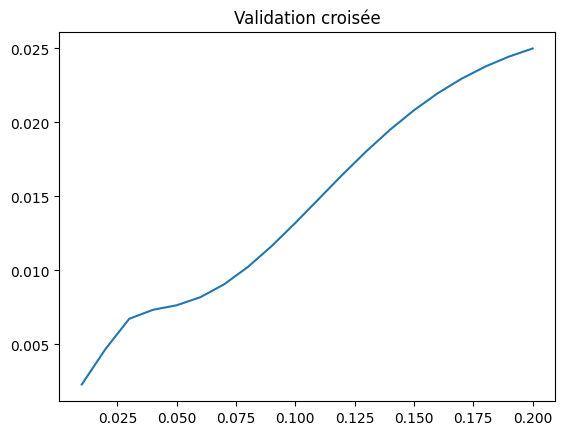

h optimal = 0.01


In [14]:
h_grid = np.linspace(0.01, 0.2, 20)
cv_errors = cross_validation_bandwidth(x, Y1, h_grid)

plt.figure()
plt.plot(h_grid, cv_errors)
plt.title("Validation croisée")
plt.show()

h_opt = h_grid[np.argmin(cv_errors)]
print("h optimal =", h_opt)
